# Week 6 Internship Project – Advanced Python for Data Analysis

## Apple Inc. (AAPL) Historical Stock Market Analysis

**Programme:** AnalystLab Africa Data Analytics Internship – Batch B  
**Topic:** Advanced Python Analysis  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, yfinance

### Project objectives
This notebook demonstrates:
- Advanced Pandas data transformation
- Data cleaning and preprocessing
- Time-series analysis
- Trend and performance analysis
- Rolling averages
- Percentage-return analysis
- Feature engineering
- Volatility analysis
- Professional data visualizations

## 1. Import Required Libraries

The notebook uses `yfinance` to obtain historical AAPL market data, Pandas for data manipulation,
NumPy for numerical calculations, and Matplotlib/Seaborn for visualization.

In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set a clean plotting style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Download AAPL Historical Data

The project requires approximately five years of historical Apple stock data.

The dates below cover approximately five years. `yfinance` uses an end date that is exclusive,
so the end date is set one day after the target date.

In [2]:
# Download approximately 5 years of Apple stock data
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2021-07-29",
    end="2026-07-30",
    auto_adjust=False,
    progress=True
)

# Flatten MultiIndex columns returned by recent yfinance versions
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Reset the index so Date becomes a regular column
df = df.reset_index()

print("Data downloaded successfully.")
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully.
Number of rows: 1,255
Number of columns: 7


In [3]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-07-29,141.962875,145.639999,146.550003,144.580002,144.690002,56699500
1,2021-07-30,142.177322,145.860001,146.330002,144.110001,144.380005,70440600
2,2021-08-02,141.845947,145.520004,146.949997,145.250000,146.360001,62880000
3,2021-08-03,143.639435,147.360001,148.039993,145.179993,145.809998,64786600
4,2021-08-04,143.239807,146.949997,147.789993,146.279999,147.270004,56368300


In [4]:
df.tail()

Price,Date,Adj Close,Close,High,Low,Open,Volume
1250,2026-07-23,321.660004,321.660004,323.299988,319.350006,321.730011,40840800
1251,2026-07-24,333.019989,333.019989,334.369995,321.619995,321.790009,47489400
1252,2026-07-27,336.910004,336.910004,339.570007,334.019989,334.540009,49604300
1253,2026-07-28,340.079987,340.079987,342.890015,335.600006,340.029999,51859000
1254,2026-07-29,338.190002,338.190002,344.570007,337.350006,339.730011,56090800


## 3. Data Exploration

Before analysis, we inspect the structure, data types, dimensions, summary statistics,
duplicates, and missing values.

In [5]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (1255, 7)

Column names:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Data types:
Price
Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

Summary statistics:


Price,Date,Adj Close,Close,High,Low,Open,Volume
count,1255,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,2024-01-26 09:32:33.466135296,196.560705,198.497721,200.478590,196.329848,198.280725,6.462483e+07
min,2021-07-29 00:00:00,122.933540,125.019997,127.769997,124.169998,126.010002,1.791060e+07
25%,2022-10-25 12:00:00,158.600983,161.985001,164.229996,159.680000,161.504997,4.552620e+07
50%,2024-01-26 00:00:00,185.291397,187.149994,188.669998,185.190002,186.830002,5.636830e+07
75%,2025-04-28 12:00:00,228.481850,229.824997,232.219994,227.549995,229.655006,7.632295e+07
max,2026-07-29 00:00:00,340.079987,340.079987,344.570007,337.350006,340.029999,3.186799e+08
std,NaN,47.105354,46.202320,46.575691,45.775095,46.127865,2.849718e+07


In [6]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

Missing values:


Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate rows: 0


## 4. Data Cleaning and Preprocessing

The following steps:
1. Convert `Date` to datetime format.
2. Sort observations chronologically.
3. Remove duplicate dates.
4. Ensure numeric market columns are numeric.
5. Handle missing numeric observations using forward filling where appropriate.

Because stock-market data only exists on trading days, we do not artificially fill dates for
weekends or public holidays.

In [7]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

# Remove duplicate dates
df = df.drop_duplicates(subset="Date").reset_index(drop=True)

# Ensure price and volume columns are numeric
numeric_columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check missing values before filling
print("Missing values before handling:")
display(df.isnull().sum())

# Forward fill numeric market values if necessary
df[numeric_columns] = df[numeric_columns].ffill()

print("\nMissing values after handling:")
display(df.isnull().sum())

print("\nCleaned dataset shape:", df.shape)

Missing values before handling:


Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


Missing values after handling:


Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


Cleaned dataset shape: (1255, 7)


In [8]:
# Set Date as the time-series index
df = df.set_index("Date")

# Verify the final structure
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-07-29,141.962875,145.639999,146.550003,144.580002,144.690002,56699500
2021-07-30,142.177322,145.860001,146.330002,144.110001,144.380005,70440600
2021-08-02,141.845947,145.520004,146.949997,145.250000,146.360001,62880000
2021-08-03,143.639435,147.360001,148.039993,145.179993,145.809998,64786600
2021-08-04,143.239807,146.949997,147.789993,146.279999,147.270004,56368300


## 5. Advanced Pandas Data Transformation

### Filtering and sorting

We can use Pandas to identify high-volume trading days and days when the closing price
exceeded a chosen threshold.

In [9]:
# Example: highest-volume trading days
highest_volume_days = (
    df[["Close", "Volume"]]
    .sort_values("Volume", ascending=False)
    .head(10)
)

display(highest_volume_days)

Price,Close,Volume
Date,,
2024-09-20,228.199997,318679900
2026-06-26,283.779999,261775500
2024-06-21,207.490005,241805100
2024-06-12,213.070007,198134300
2021-12-17,171.139999,195432700
2025-04-09,198.850006,184395900
2022-05-12,142.559998,182602000
2022-01-28,170.330002,179935700
2021-11-30,165.300003,174048100


In [10]:
# Example: observations where closing price is above its dataset median
median_close = df["Close"].median()

above_median = df[df["Close"] > median_close].copy()

print(f"Median closing price: ${median_close:.2f}")
print(f"Number of trading days above the median: {len(above_median):,}")

Median closing price: $187.15
Number of trading days above the median: 627


## 6. Feature Engineering

Several new variables are created to support deeper analysis:

- **Daily_Price_Change:** absolute change in closing price from the previous trading day.
- **Daily_Return:** percentage change in closing price.
- **MA_7:** 7-trading-day moving average.
- **MA_30:** 30-trading-day moving average.
- **Daily_Range:** difference between the daily high and low.
- **Range_Percent:** daily range relative to the opening price.
- **Volatility_30D:** rolling 30-trading-day standard deviation of daily returns.
- **Month:** month associated with each observation.
- **Year:** year associated with each observation.

In [11]:
# Daily price change
df["Daily_Price_Change"] = df["Close"].diff()

# Daily percentage return
df["Daily_Return"] = df["Close"].pct_change() * 100

# Moving averages
df["MA_7"] = df["Close"].rolling(window=7).mean()
df["MA_30"] = df["Close"].rolling(window=30).mean()

# Daily trading range
df["Daily_Range"] = df["High"] - df["Low"]

# Trading range as a percentage of opening price
df["Range_Percent"] = (df["Daily_Range"] / df["Open"]) * 100

# 30-day rolling volatility
df["Volatility_30D"] = df["Daily_Return"].rolling(window=30).std()

# Time-based features
df["Year"] = df.index.year
df["Month"] = df.index.month
df["Month_Name"] = df.index.strftime("%b")

display(df.head(10))

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Price_Change,Daily_Return,MA_7,MA_30,Daily_Range,Range_Percent,Volatility_30D,Year,Month,Month_Name
Date,,,,,,,,,,,,,,,,
2021-07-29,141.962875,145.639999,146.550003,144.580002,144.690002,56699500,NaN,NaN,NaN,NaN,1.970001,1.361532,NaN,2021,7,Jul
2021-07-30,142.177322,145.860001,146.330002,144.110001,144.380005,70440600,0.220001,0.151058,NaN,NaN,2.220001,1.537610,NaN,2021,7,Jul
2021-08-02,141.845947,145.520004,146.949997,145.250000,146.360001,62880000,-0.339996,-0.233098,NaN,NaN,1.699997,1.161517,NaN,2021,8,Aug
2021-08-03,143.639435,147.360001,148.039993,145.179993,145.809998,64786600,1.839996,1.264428,NaN,NaN,2.860001,1.961457,NaN,2021,8,Aug
2021-08-04,143.239807,146.949997,147.789993,146.279999,147.270004,56368300,-0.410004,-0.278233,NaN,NaN,1.509995,1.025324,NaN,2021,8,Aug
2021-08-05,143.347000,147.059998,147.839996,146.169998,146.979996,46397700,0.110001,0.074856,NaN,NaN,1.669998,1.136208,NaN,2021,8,Aug
2021-08-06,142.663666,146.139999,147.110001,145.630005,146.350006,54126800,-0.919998,-0.625594,146.361428,NaN,1.479996,1.011271,NaN,2021,8,Aug
2021-08-09,142.614853,146.089996,146.699997,145.520004,146.199997,48908700,-0.050003,-0.034216,146.425714,NaN,1.179993,0.807109,NaN,2021,8,Aug
2021-08-10,142.136490,145.600006,147.710007,145.300003,146.440002,69023100,-0.489990,-0.335403,146.388572,NaN,2.410004,1.645728,NaN,2021,8,Aug


## 7. Monthly Performance Analysis

Monthly aggregation provides a higher-level view of the stock's performance.
We calculate the first and last closing prices in each month, monthly return,
average trading volume, and average daily volatility.

In [12]:
monthly = df.resample("ME").agg(
    Start_Price=("Close", "first"),
    End_Price=("Close", "last"),
    Average_Close=("Close", "mean"),
    Average_Volume=("Volume", "mean"),
    High=("High", "max"),
    Low=("Low", "min")
)

monthly["Monthly_Return"] = (
    monthly["End_Price"].pct_change() * 100
)

monthly["Monthly_Range"] = monthly["High"] - monthly["Low"]

display(monthly.head(12))

,Start_Price,End_Price,Average_Close,Average_Volume,High,Low,Monthly_Return,Monthly_Range
Date,,,,,,,,
2021-07-31,145.639999,145.860001,145.750000,6.357005e+07,146.550003,144.110001,NaN,2.440002
2021-08-31,145.520004,151.830002,148.177727,6.643376e+07,153.490005,144.500000,4.092967,8.990005
2021-09-30,152.509995,141.500000,148.306190,8.561120e+07,157.259995,141.270004,-6.803663,15.989990
2021-10-31,142.649994,149.800003,145.563809,7.452758e+07,153.169998,138.270004,5.865727,14.899994
2021-11-30,148.960007,165.300003,154.255716,8.052519e+07,165.699997,147.479996,10.347129,18.220001
2021-12-31,164.770004,177.570007,173.552727,1.111258e+08,182.130005,157.800003,7.422870,24.330002
2022-01-31,182.009995,174.779999,169.861500,1.054223e+08,182.940002,154.699997,-1.571216,28.240005
2022-02-28,174.610001,165.119995,169.830001,8.565875e+07,176.649994,152.000000,-5.526950,24.649994
2022-03-31,163.199997,174.610001,165.310435,9.481740e+07,179.610001,150.100006,5.747339,29.509995


## 8. Yearly Performance Summary

This table summarizes annual closing prices, annual returns, and average trading volume.

In [13]:
yearly = df.resample("YE").agg(
    Start_Price=("Close", "first"),
    End_Price=("Close", "last"),
    Average_Close=("Close", "mean"),
    Average_Volume=("Volume", "mean"),
    Year_High=("High", "max"),
    Year_Low=("Low", "min")
)

yearly["Annual_Return"] = yearly["End_Price"].pct_change() * 100

display(yearly)

,Start_Price,End_Price,Average_Close,Average_Volume,Year_High,Year_Low,Annual_Return
Date,,,,,,,
2021-12-31,145.639999,177.570007,153.946881,8.337058e+07,182.130005,138.270004,NaN
2022-12-31,182.009995,129.929993,154.835060,8.791038e+07,182.940002,125.870003,-26.828863
2023-12-31,125.070000,192.529999,172.549000,5.922355e+07,199.619995,124.169998,48.179797
2024-12-31,185.639999,250.419998,207.205912,5.710678e+07,260.100006,164.080002,30.068041
2025-12-31,243.850006,271.859985,232.240520,5.417578e+07,288.619995,169.210007,8.561611
2026-12-31,271.010010,338.190002,280.122797,5.042324e+07,344.570007,243.419998,24.398595


## 9. Visualization 1 – AAPL Closing Price Trend

This visualization shows the long-term movement of Apple's closing stock price over the
analysis period.

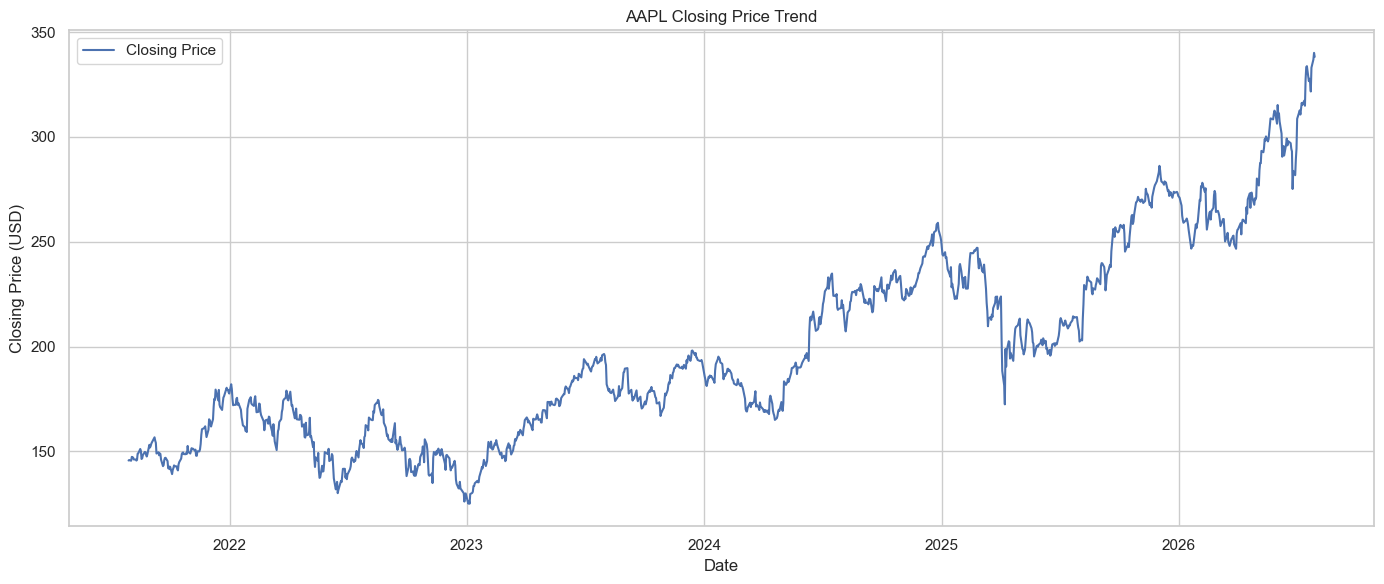

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Closing Price")

plt.title("AAPL Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("../Visualizations/APPL_CPT.png")
plt.show()

## 10. Visualization 2 – Trading Volume Trend

Trading volume represents the number of shares traded during each session.
Large changes in volume can indicate periods of increased market activity.

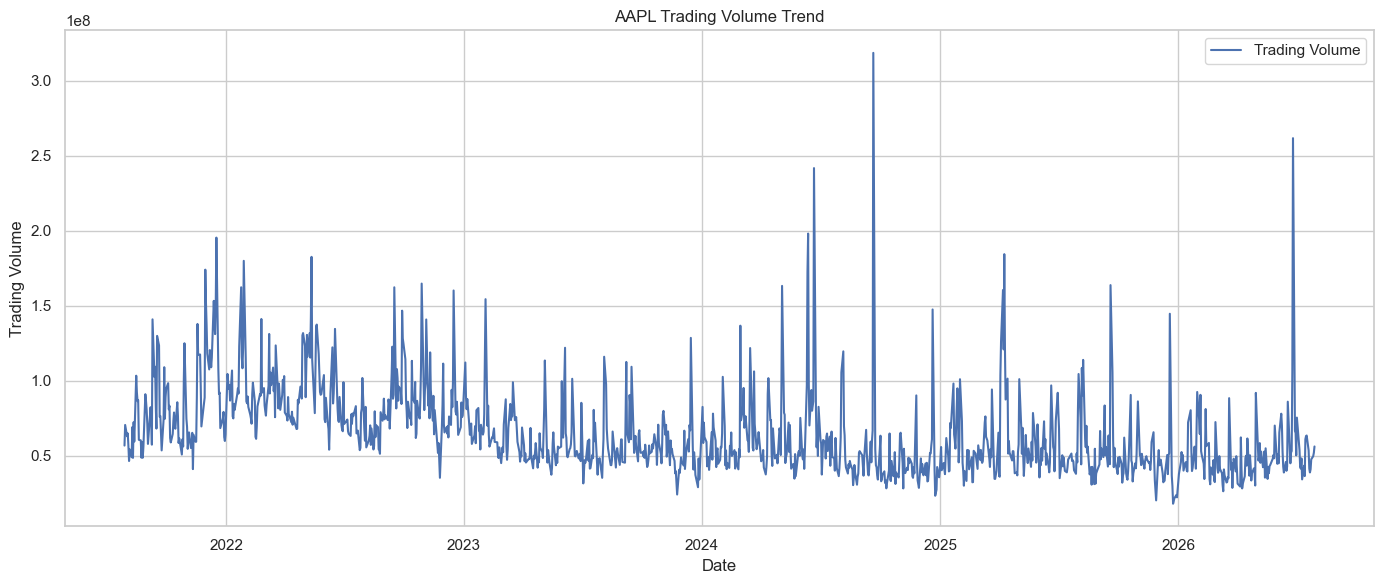

In [27]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Volume"], label="Trading Volume")

plt.title("AAPL Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.legend()
plt.tight_layout()
plt.savefig("../Visualizations/TVT.png")
plt.show()

## 11. Visualization 3 – Moving Average Analysis

The 7-day and 30-day moving averages smooth short-term price fluctuations and make
underlying trends easier to observe.

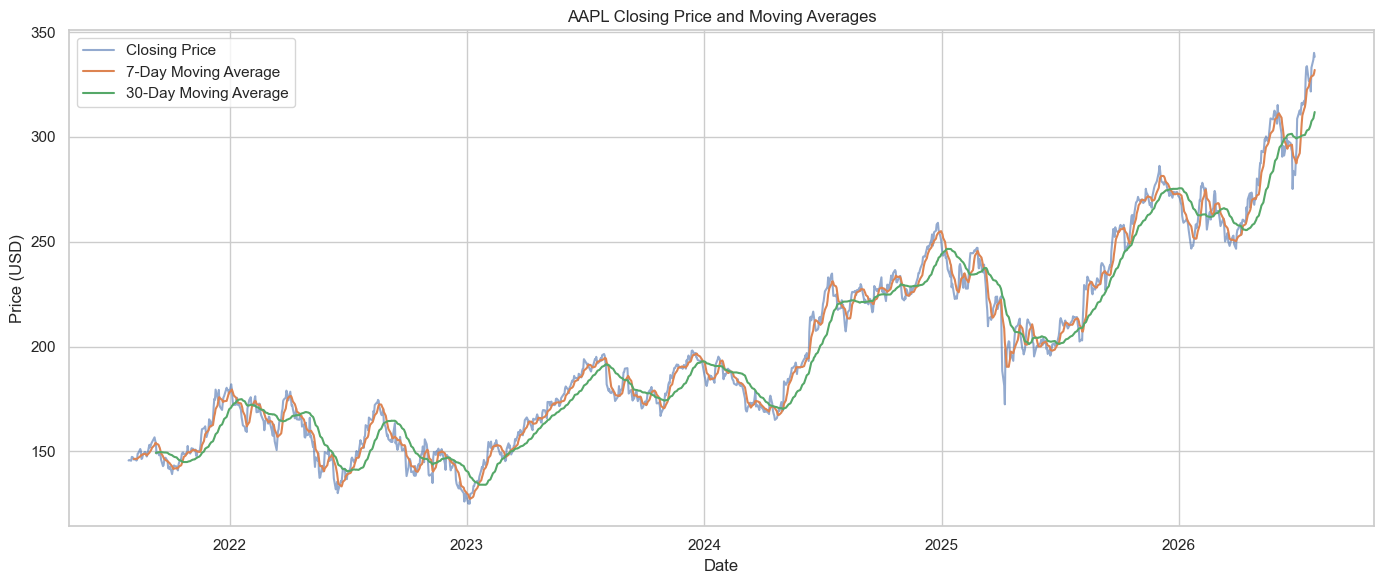

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Closing Price", alpha=0.6)
plt.plot(df.index, df["MA_7"], label="7-Day Moving Average")
plt.plot(df.index, df["MA_30"], label="30-Day Moving Average")

plt.title("AAPL Closing Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("../Visualizations/MAA.png")
plt.show()

## 12. Visualization 4 – Daily Returns Analysis

Daily returns show the percentage change in the closing price from one trading session
to the next. Values close to zero indicate relatively small daily movements, while larger
positive or negative values indicate stronger movements.

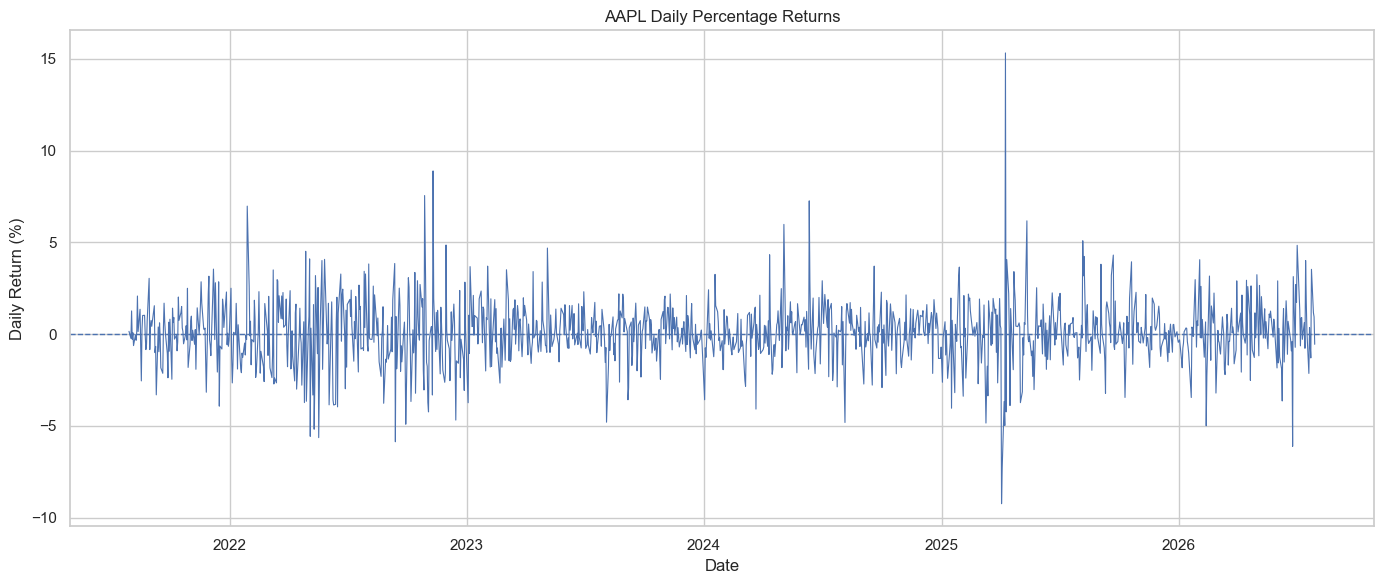

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Daily_Return"], linewidth=0.8)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("AAPL Daily Percentage Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.tight_layout()
plt.savefig("../Visualizations/DRA.png")
plt.show()

## 13. Visualization 5 – 30-Day Rolling Volatility

Rolling volatility measures how much daily returns have varied over a moving 30-trading-day
window. Higher values indicate periods of greater short-term price variability.

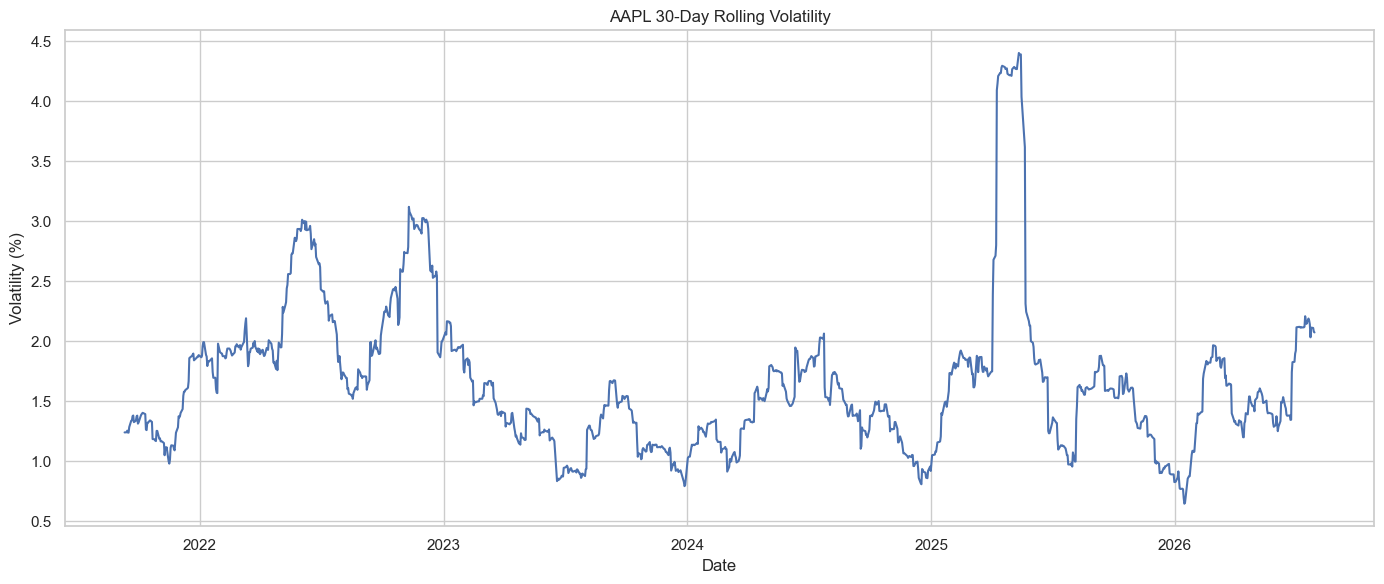

In [30]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Volatility_30D"])

plt.title("AAPL 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.tight_layout()
plt.savefig("../Visualizations/DRV.png")
plt.show()

## 14. Visualization 6 – Monthly Returns

Monthly returns provide a less noisy view of performance than daily returns.

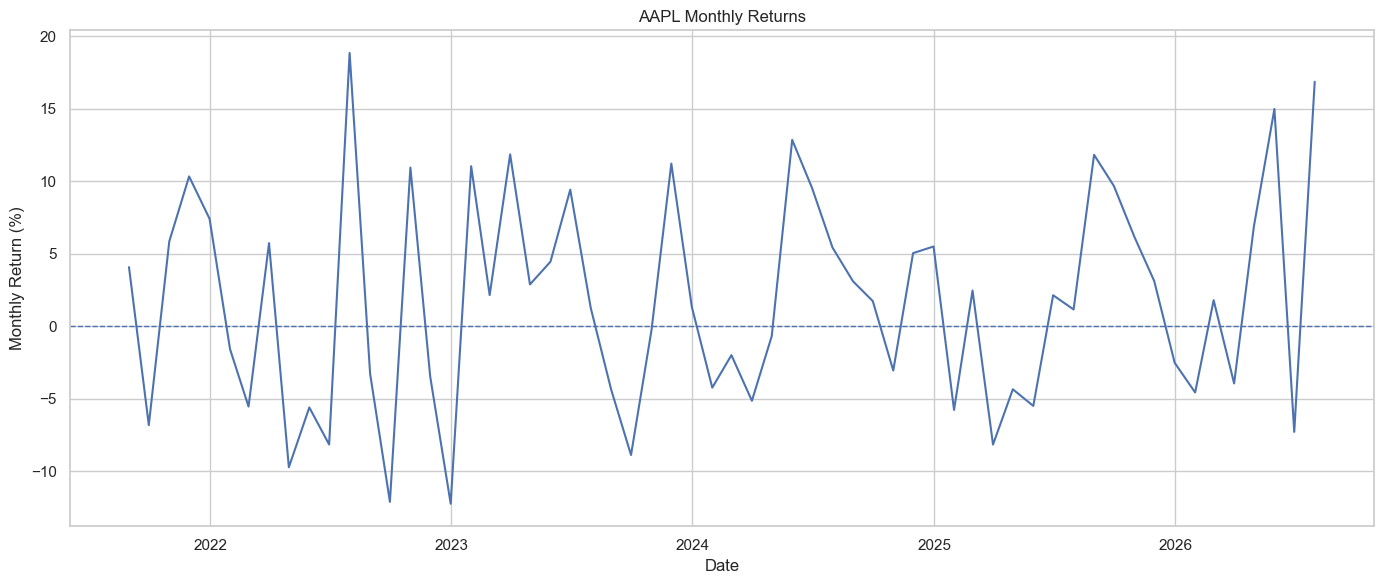

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(monthly.index, monthly["Monthly_Return"])

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("AAPL Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.tight_layout()
plt.savefig("../Visualizations/MR.png")
plt.show()

## 15. Performance Metrics

We calculate several overall measures that can be used in the final insight summary.

In [32]:
# Remove the initial NaN return
valid_returns = df["Daily_Return"].dropna()

total_return = ((df["Close"].iloc[-1] / df["Close"].iloc[0]) - 1) * 100
average_daily_return = valid_returns.mean()
daily_volatility = valid_returns.std()
best_day = valid_returns.max()
worst_day = valid_returns.min()

print(f"Starting closing price: ${df['Close'].iloc[0]:.2f}")
print(f"Ending closing price: ${df['Close'].iloc[-1]:.2f}")
print(f"Overall price return: {total_return:.2f}%")
print(f"Average daily return: {average_daily_return:.4f}%")
print(f"Daily return volatility: {daily_volatility:.2f}%")
print(f"Best daily return: {best_day:.2f}%")
print(f"Worst daily return: {worst_day:.2f}%")

Starting closing price: $145.64
Ending closing price: $338.19
Overall price return: 132.21%
Average daily return: 0.0825%
Daily return volatility: 1.75%
Best daily return: 15.33%
Worst daily return: -9.25%


## 16. Best and Worst Monthly Returns

These tables identify the months with the strongest positive and negative performance.

In [33]:
best_months = monthly["Monthly_Return"].dropna().nlargest(10)
worst_months = monthly["Monthly_Return"].dropna().nsmallest(10)

print("Top 10 monthly returns:")
display(best_months.to_frame("Monthly_Return_%"))

print("Bottom 10 monthly returns:")
display(worst_months.to_frame("Monthly_Return_%"))

Top 10 monthly returns:


,Monthly_Return_%
Date,
2022-07-31,18.863365
2026-07-31,16.875180
2026-05-31,15.002760
2024-05-31,12.869135
2023-03-31,11.864860
2025-08-31,11.836966
2023-11-30,11.231476
2023-01-31,11.052106
2022-10-31,10.955137


Bottom 10 monthly returns:


,Monthly_Return_%
Date,
2022-12-31,-12.227255
2022-09-30,-12.097700
2022-04-30,-9.713079
2023-09-30,-8.867828
2025-03-31,-8.150013
2022-06-30,-8.142969
2026-06-30,-7.274246
2021-09-30,-6.803663
2025-01-31,-5.758325


## 17. Highest and Lowest Closing Prices

These values provide useful reference points for the overall price range during the period.

In [34]:
highest_close_date = df["Close"].idxmax()
lowest_close_date = df["Close"].idxmin()

print(
    f"Highest closing price: ${df.loc[highest_close_date, 'Close']:.2f} "
    f"on {highest_close_date.date()}"
)

print(
    f"Lowest closing price: ${df.loc[lowest_close_date, 'Close']:.2f} "
    f"on {lowest_close_date.date()}"
)

Highest closing price: $340.08 on 2026-07-28
Lowest closing price: $125.02 on 2023-01-05


## 18. Feature Correlation Analysis

A correlation matrix provides a quick view of linear relationships between selected
numeric variables. Correlation does not imply causation.

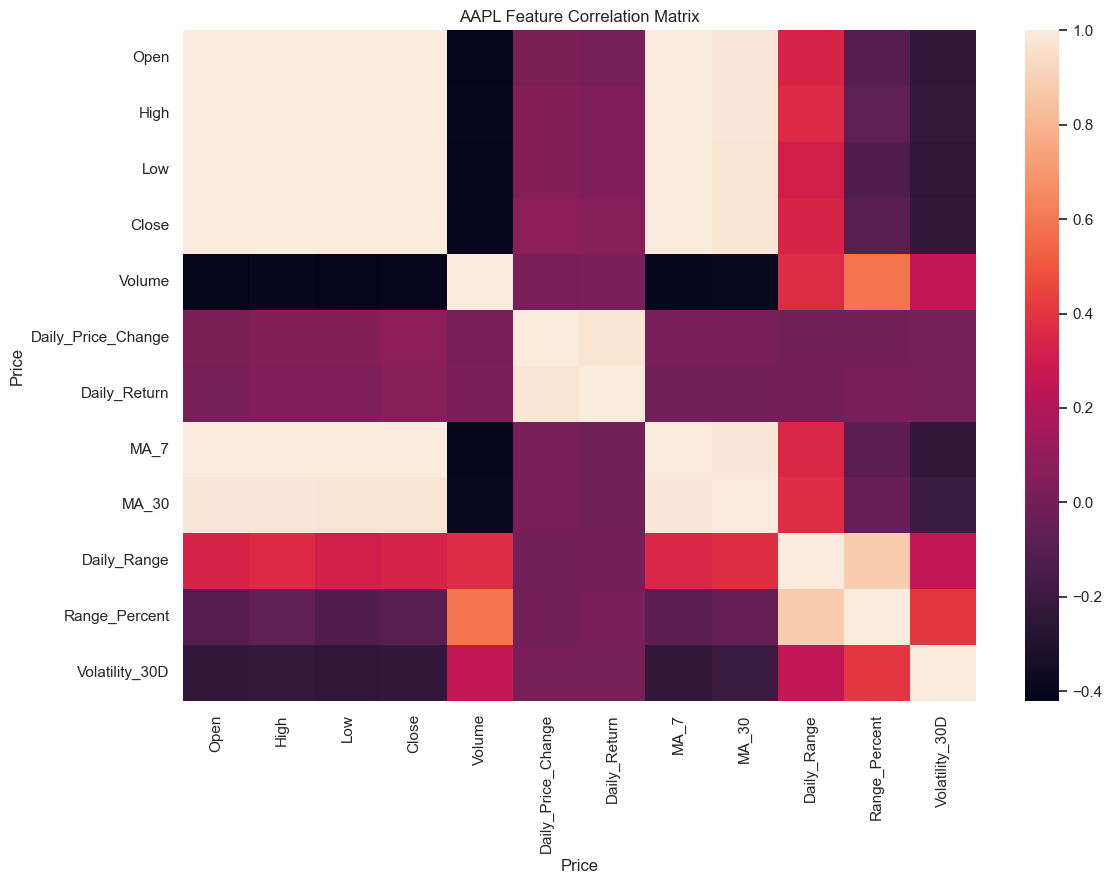

In [35]:
correlation_columns = [
    "Open", "High", "Low", "Close", "Volume",
    "Daily_Price_Change", "Daily_Return",
    "MA_7", "MA_30", "Daily_Range",
    "Range_Percent", "Volatility_30D"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=False)
plt.title("AAPL Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../Visualizations/FCA.png")
plt.show()

## 19. Final Feature Dataset

The final dataset contains the original market variables plus the engineered features
used throughout the analysis.

In [36]:
final_columns = [
    "Open", "High", "Low", "Close", "Adj Close", "Volume",
    "Daily_Price_Change", "Daily_Return",
    "MA_7", "MA_30",
    "Daily_Range", "Range_Percent",
    "Volatility_30D",
    "Year", "Month", "Month_Name"
]

final_df = df[final_columns].copy()

display(final_df.head())
print("Final dataset shape:", final_df.shape)

Price,Open,High,Low,Close,Adj Close,Volume,Daily_Price_Change,Daily_Return,MA_7,MA_30,Daily_Range,Range_Percent,Volatility_30D,Year,Month,Month_Name
Date,,,,,,,,,,,,,,,,
2021-07-29,144.690002,146.550003,144.580002,145.639999,141.962875,56699500,NaN,NaN,NaN,NaN,1.970001,1.361532,NaN,2021,7,Jul
2021-07-30,144.380005,146.330002,144.110001,145.860001,142.177322,70440600,0.220001,0.151058,NaN,NaN,2.220001,1.537610,NaN,2021,7,Jul
2021-08-02,146.360001,146.949997,145.250000,145.520004,141.845947,62880000,-0.339996,-0.233098,NaN,NaN,1.699997,1.161517,NaN,2021,8,Aug
2021-08-03,145.809998,148.039993,145.179993,147.360001,143.639435,64786600,1.839996,1.264428,NaN,NaN,2.860001,1.961457,NaN,2021,8,Aug
2021-08-04,147.270004,147.789993,146.279999,146.949997,143.239807,56368300,-0.410004,-0.278233,NaN,NaN,1.509995,1.025324,NaN,2021,8,Aug


Final dataset shape: (1255, 16)


In [37]:
# Save the cleaned and feature-engineered dataset
final_df.to_csv("../Data/AAPL_Week6_Feature_Engineered.csv")

# Save the monthly summary
monthly.to_csv("../Data/AAPL_Monthly_Summary.csv")

# Save the yearly summary
yearly.to_csv("../Data/AAPL_Yearly_Summary.csv")

print("Files saved successfully.")

Files saved successfully.


## 20. Key Findings

Use the numerical results generated above to describe:

1. The overall direction of AAPL's closing price over the five-year period.
2. The difference between short-term and longer-term trends using the 7-day and 30-day moving averages.
3. The periods with unusually high trading volume.
4. The strongest and weakest daily/monthly return periods.
5. Periods of relatively high 30-day rolling volatility.
6. How the engineered features support interpretation of stock-market behaviour.

### Important interpretation note

This analysis is descriptive rather than predictive. The identified trends and volatility
patterns describe historical market behaviour and should not be treated as guaranteed
future performance.

## 21. Conclusion

This project demonstrates the use of advanced Python and Pandas techniques for analysing
historical financial time-series data. The analysis combines data cleaning, transformation,
time-based aggregation, rolling-window calculations, percentage changes, feature engineering,
and visualization.

The engineered variables make it easier to study price momentum, daily performance,
monthly performance, trading activity, and short-term volatility. Together, these techniques
provide a structured foundation for more advanced financial time-series and predictive
modelling work.

## 22. Week 6 Deliverables Checklist

- [x] Data loading
- [x] Data exploration
- [x] Data cleaning and preprocessing
- [x] Pandas data transformation
- [x] Time-series analysis
- [x] Feature engineering
- [x] Closing price visualization
- [x] Trading volume visualization
- [x] Moving average visualization
- [x] Daily returns visualization
- [x] Additional volatility visualization
- [x] Monthly returns analysis
- [x] Key findings section
- [x] Conclusion
- [x] Export of feature-engineered data